In [3]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DOE ANALYSIS

In [ ]:
runs_no_latency_dir = Path(r"R:\sescott1\Masters\thesis\potential_codes\pymarketsim\runs")
runs_latency_dir = Path(r"R:\sescott1\Masters\thesis\potential_codes\pymarketsim\runs_latency")

def load_run_summary(run_path: Path):
    config_path = run_path / "config.json"
    summary_path = run_path / "summary.json"

    if not config_path.exists() or not summary_path.exists():
        return None

    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    with open(summary_path, "r", encoding="utf-8") as f:
        summary = json.load(f)

    return {
        "run_name": run_path.name,
        **config,
        **summary,
    }

def load_all_runs(base_dir: Path, condition_label: str):
    rows = []
    for p in base_dir.iterdir():
        if p.is_dir() and p.name.startswith("dqn_"):
            row = load_run_summary(p)
            if row is not None:
                row["condition"] = condition_label
                row["run_path"] = str(p)
                rows.append(row)
    return pd.DataFrame(rows)

df_no_latency = load_all_runs(runs_no_latency_dir, "No latency")
df_latency = load_all_runs(runs_latency_dir, "Latency")

print("No-latency runs:", len(df_no_latency))
print("Latency runs:", len(df_latency))

No-latency runs: 5
Latency runs: 4


In [4]:
display(
    df_no_latency[[
        "run_name", "run_tag", "lambda_invalid", "train_freq",
        "mean_return_first", "mean_return_last",
        "mean_invalid_first", "mean_invalid_last",
        "best_episode_return"
    ]].sort_values("run_name")
)

display(
    df_latency[[
        "run_name", "run_tag", "lambda_invalid", "train_freq",
        "mean_return_first", "mean_return_last",
        "mean_invalid_first", "mean_invalid_last",
        "best_episode_return"
    ]].sort_values("run_name")
)

,run_name,run_tag,lambda_invalid,train_freq,mean_return_first,mean_return_last,mean_invalid_first,mean_invalid_last,best_episode_return
0,dqn_AAPL_XOM_A_pen1_tf4_20260406_163746_542248,A_pen1_tf4,1.0,4,-16.909656,4.115038,2.19,3.06,26.513769
1,dqn_AAPL_XOM_B_pen2_tf4_20260406_164012_668202,B_pen2_tf4,2.0,4,-17.048013,8.857072,2.21,0.19,39.854651
2,dqn_AAPL_XOM_C_pen1_tf1_20260406_164237_219946,C_pen1_tf1,1.0,1,-11.514600,12.762303,2.28,0.15,54.398792
3,dqn_AAPL_XOM_D_pen2_tf1_20260406_164546_883537,D_pen2_tf1,2.0,1,-17.076452,11.082956,1.95,0.16,44.795007
4,dqn_AAPL_XOM_test_run_20260406_163312_755597,test_run,1.0,4,-14.806243,6.949285,2.23,1.46,35.028295


,run_name,run_tag,lambda_invalid,train_freq,mean_return_first,mean_return_last,mean_invalid_first,mean_invalid_last,best_episode_return
0,dqn_AAPL_XOM_A_pen1_tf4_lat1_20260406_202459_2...,A_pen1_tf4_lat1,1.0,4,-14.632539,9.135640,2.27,2.24,32.848792
1,dqn_AAPL_XOM_B_pen2_tf4_lat1_20260406_202833_6...,B_pen2_tf4_lat1,2.0,4,-17.259820,7.841294,2.35,0.35,32.105023
2,dqn_AAPL_XOM_C_pen1_tf1_lat1_20260406_203206_3...,C_pen1_tf1_lat1,1.0,1,-12.792389,13.049795,2.13,0.15,44.627411
3,dqn_AAPL_XOM_D_pen2_tf1_lat1_20260406_203611_9...,D_pen2_tf1_lat1,2.0,1,-16.559553,12.309179,1.97,0.20,46.116834


In [5]:
doe_tags = ["A_", "B_", "C_", "D_"]

def keep_doe_only(df):
    return df[df["run_tag"].astype(str).str.startswith(tuple(doe_tags), na=False)].copy()

df_no_latency_doe = keep_doe_only(df_no_latency)
df_latency_doe = keep_doe_only(df_latency)

print("No-latency DOE runs:", len(df_no_latency_doe))
print("Latency DOE runs:", len(df_latency_doe))

No-latency DOE runs: 4
Latency DOE runs: 4


In [6]:
summary_cols = [
    "condition",
    "run_tag",
    "lambda_invalid",
    "train_freq",
    "mean_return_first",
    "mean_return_last",
    "mean_invalid_first",
    "mean_invalid_last",
    "best_episode_return",
    "mean_steps_last",
]

summary_no_latency = df_no_latency_doe[summary_cols].sort_values(
    ["lambda_invalid", "train_freq"]
).reset_index(drop=True)

summary_latency = df_latency_doe[summary_cols].sort_values(
    ["lambda_invalid", "train_freq"]
).reset_index(drop=True)

print("DOE without latency")
display(summary_no_latency)

print("DOE with latency")
display(summary_latency)

DOE without latency


,condition,run_tag,lambda_invalid,train_freq,mean_return_first,mean_return_last,mean_invalid_first,mean_invalid_last,best_episode_return,mean_steps_last
0,No latency,C_pen1_tf1,1.0,1,-11.514600,12.762303,2.28,0.15,54.398792,9.8
1,No latency,A_pen1_tf4,1.0,4,-16.909656,4.115038,2.19,3.06,26.513769,9.8
2,No latency,D_pen2_tf1,2.0,1,-17.076452,11.082956,1.95,0.16,44.795007,9.8
3,No latency,B_pen2_tf4,2.0,4,-17.048013,8.857072,2.21,0.19,39.854651,9.8


DOE with latency


,condition,run_tag,lambda_invalid,train_freq,mean_return_first,mean_return_last,mean_invalid_first,mean_invalid_last,best_episode_return,mean_steps_last
0,Latency,C_pen1_tf1_lat1,1.0,1,-12.792389,13.049795,2.13,0.15,44.627411,9.8
1,Latency,A_pen1_tf4_lat1,1.0,4,-14.632539,9.135640,2.27,2.24,32.848792,9.8
2,Latency,D_pen2_tf1_lat1,2.0,1,-16.559553,12.309179,1.97,0.20,46.116834,9.8
3,Latency,B_pen2_tf4_lat1,2.0,4,-17.259820,7.841294,2.35,0.35,32.105023,9.8


In [7]:
latex_no_latency = summary_no_latency.to_latex(
    index=False,
    float_format="%.3f",
    caption="DOE results for DQN training without latency.",
    label="tab:rl_doe_no_latency"
)

latex_latency = summary_latency.to_latex(
    index=False,
    float_format="%.3f",
    caption="DOE results for DQN training with latency.",
    label="tab:rl_doe_latency"
)

print(latex_no_latency)
print()
print(latex_latency)

\begin{table}
\caption{DOE results for DQN training without latency.}
\label{tab:rl_doe_no_latency}
\begin{tabular}{llrrrrrrrr}
\toprule
condition & run_tag & lambda_invalid & train_freq & mean_return_first & mean_return_last & mean_invalid_first & mean_invalid_last & best_episode_return & mean_steps_last \\
\midrule
No latency & C_pen1_tf1 & 1.000 & 1 & -11.515 & 12.762 & 2.280 & 0.150 & 54.399 & 9.800 \\
No latency & A_pen1_tf4 & 1.000 & 4 & -16.910 & 4.115 & 2.190 & 3.060 & 26.514 & 9.800 \\
No latency & D_pen2_tf1 & 2.000 & 1 & -17.076 & 11.083 & 1.950 & 0.160 & 44.795 & 9.800 \\
No latency & B_pen2_tf4 & 2.000 & 4 & -17.048 & 8.857 & 2.210 & 0.190 & 39.855 & 9.800 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{DOE results for DQN training with latency.}
\label{tab:rl_doe_latency}
\begin{tabular}{llrrrrrrrr}
\toprule
condition & run_tag & lambda_invalid & train_freq & mean_return_first & mean_return_last & mean_invalid_first & mean_invalid_last & best_episode_ret

In [8]:
df_compare = pd.concat([summary_no_latency, summary_latency], ignore_index=True)
display(df_compare.sort_values(["condition", "lambda_invalid", "train_freq"]))

,condition,run_tag,lambda_invalid,train_freq,mean_return_first,mean_return_last,mean_invalid_first,mean_invalid_last,best_episode_return,mean_steps_last
4,Latency,C_pen1_tf1_lat1,1.0,1,-12.792389,13.049795,2.13,0.15,44.627411,9.8
5,Latency,A_pen1_tf4_lat1,1.0,4,-14.632539,9.135640,2.27,2.24,32.848792,9.8
6,Latency,D_pen2_tf1_lat1,2.0,1,-16.559553,12.309179,1.97,0.20,46.116834,9.8
7,Latency,B_pen2_tf4_lat1,2.0,4,-17.259820,7.841294,2.35,0.35,32.105023,9.8
0,No latency,C_pen1_tf1,1.0,1,-11.514600,12.762303,2.28,0.15,54.398792,9.8
1,No latency,A_pen1_tf4,1.0,4,-16.909656,4.115038,2.19,3.06,26.513769,9.8
2,No latency,D_pen2_tf1,2.0,1,-17.076452,11.082956,1.95,0.16,44.795007,9.8
3,No latency,B_pen2_tf4,2.0,4,-17.048013,8.857072,2.21,0.19,39.854651,9.8


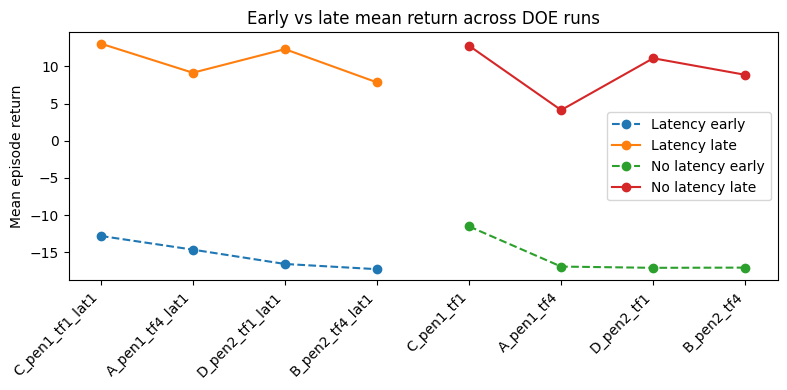

In [9]:
plt.figure(figsize=(8, 4))

for condition, grp in df_compare.groupby("condition"):
    grp = grp.sort_values(["lambda_invalid", "train_freq"])
    x = grp["run_tag"].astype(str)
    plt.plot(x, grp["mean_return_first"], marker="o", linestyle="--", label=f"{condition} early")
    plt.plot(x, grp["mean_return_last"], marker="o", linestyle="-", label=f"{condition} late")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean episode return")
plt.title("Early vs late mean return across DOE runs")
plt.legend()
plt.tight_layout()
plt.show()

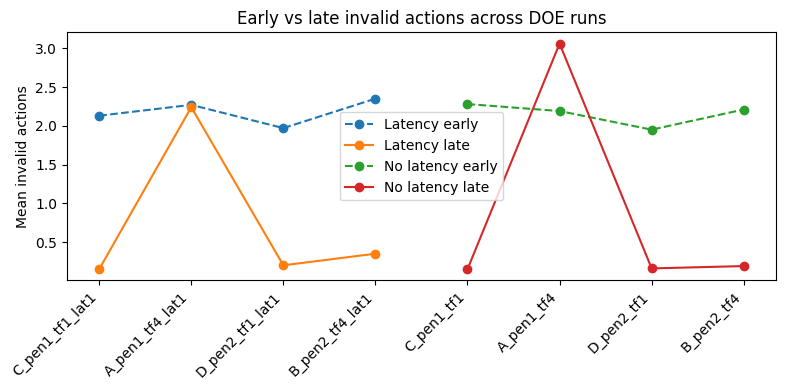

In [10]:
plt.figure(figsize=(8, 4))

for condition, grp in df_compare.groupby("condition"):
    grp = grp.sort_values(["lambda_invalid", "train_freq"])
    x = grp["run_tag"].astype(str)
    plt.plot(x, grp["mean_invalid_first"], marker="o", linestyle="--", label=f"{condition} early")
    plt.plot(x, grp["mean_invalid_last"], marker="o", linestyle="-", label=f"{condition} late")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean invalid actions")
plt.title("Early vs late invalid actions across DOE runs")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def load_episode_log(run_path_str: str):
    run_path = Path(run_path_str)
    log_path = run_path / "episode_log.jsonl"

    rows = []
    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))

    return pd.DataFrame(rows)


# example: choose best no-latency run by highest late mean return
best_no_latency_row = df_no_latency_doe.sort_values("mean_return_last", ascending=False).iloc[0]
best_no_latency_run = best_no_latency_row["run_path"]

print("Best no-latency run:", best_no_latency_run)

df_ep_no_latency = load_episode_log(best_no_latency_run)
df_ep_no_latency.head()

Best no-latency run: R:\sescott1\Masters\thesis\potential_codes\pymarketsim\runs\dqn_AAPL_XOM_C_pen1_tf1_20260406_164237_219946


,episode,episode_return,episode_steps,invalid_actions,final_net_worth,avg_loss,epsilon,buffer_size,total_steps
0,0,-4.824049,16,0,99995.175951,NaN,0.99696,16,16
1,1,-36.440002,6,3,99966.559998,NaN,0.99582,22,22
2,2,2.516393,12,3,100005.516393,NaN,0.99354,34,34
3,3,-11.615327,8,0,99988.384673,NaN,0.99202,42,42
4,4,-30.319731,7,0,99969.680269,NaN,0.99069,49,49


In [13]:
best_latency_row = df_latency_doe.sort_values("mean_return_last", ascending=False).iloc[0]
best_latency_run = best_latency_row["run_path"]

print("Best latency run:", best_latency_run)

df_ep_latency = load_episode_log(best_latency_run)
df_ep_latency.head()

Best latency run: R:\sescott1\Masters\thesis\potential_codes\pymarketsim\runs_latency\dqn_AAPL_XOM_C_pen1_tf1_lat1_20260406_203206_316867


,episode,episode_return,episode_steps,invalid_actions,final_net_worth,avg_loss,epsilon,buffer_size,total_steps
0,0,-4.824049,16,0,99995.175951,NaN,0.99696,16,16
1,1,-36.440002,6,3,99966.559998,NaN,0.99582,22,22
2,2,2.516393,12,3,100005.516393,NaN,0.99354,34,34
3,3,-11.615327,8,0,99988.384673,NaN,0.99202,42,42
4,4,-30.319731,7,0,99969.680269,NaN,0.99069,49,49


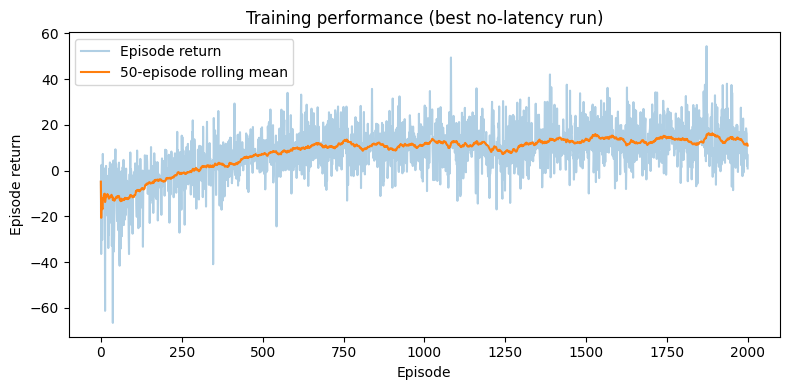

In [14]:
df_ep_no_latency["rolling_return_50"] = df_ep_no_latency["episode_return"].rolling(50, min_periods=1).mean()

plt.figure(figsize=(8, 4))
plt.plot(df_ep_no_latency["episode"], df_ep_no_latency["episode_return"], alpha=0.35, label="Episode return")
plt.plot(df_ep_no_latency["episode"], df_ep_no_latency["rolling_return_50"], label="50-episode rolling mean")
plt.xlabel("Episode")
plt.ylabel("Episode return")
plt.title("Training performance (best no-latency run)")
plt.legend()
plt.tight_layout()
plt.show()

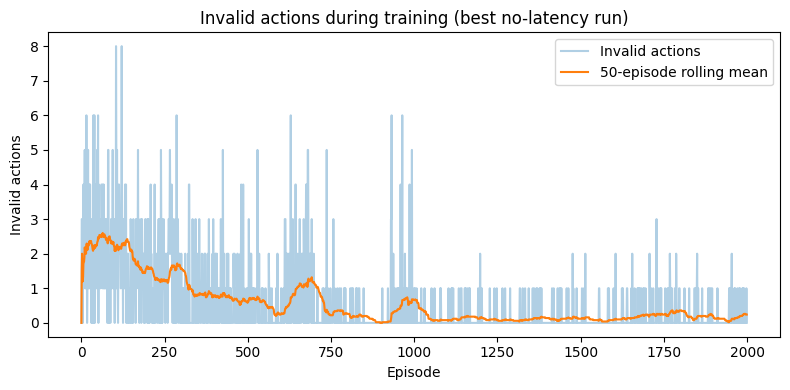

In [15]:
df_ep_no_latency["rolling_invalid_50"] = df_ep_no_latency["invalid_actions"].rolling(50, min_periods=1).mean()

plt.figure(figsize=(8, 4))
plt.plot(df_ep_no_latency["episode"], df_ep_no_latency["invalid_actions"], alpha=0.35, label="Invalid actions")
plt.plot(df_ep_no_latency["episode"], df_ep_no_latency["rolling_invalid_50"], label="50-episode rolling mean")
plt.xlabel("Episode")
plt.ylabel("Invalid actions")
plt.title("Invalid actions during training (best no-latency run)")
plt.legend()
plt.tight_layout()
plt.show()

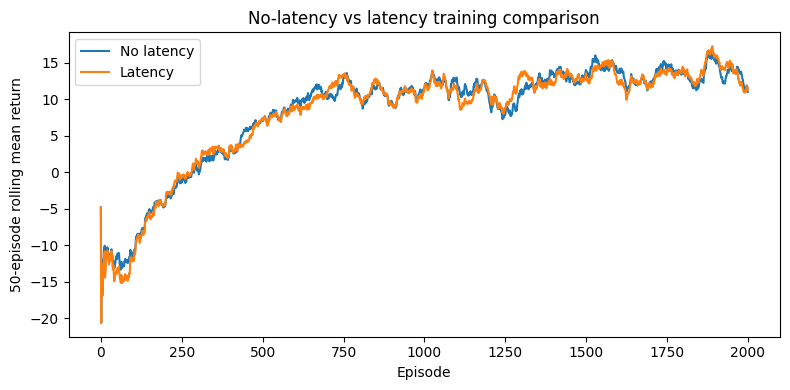

In [16]:
df_ep_latency["rolling_return_50"] = df_ep_latency["episode_return"].rolling(50, min_periods=1).mean()

plt.figure(figsize=(8, 4))
plt.plot(df_ep_no_latency["episode"], df_ep_no_latency["rolling_return_50"], label="No latency")
plt.plot(df_ep_latency["episode"], df_ep_latency["rolling_return_50"], label="Latency")
plt.xlabel("Episode")
plt.ylabel("50-episode rolling mean return")
plt.title("No-latency vs latency training comparison")
plt.legend()
plt.tight_layout()
plt.show()

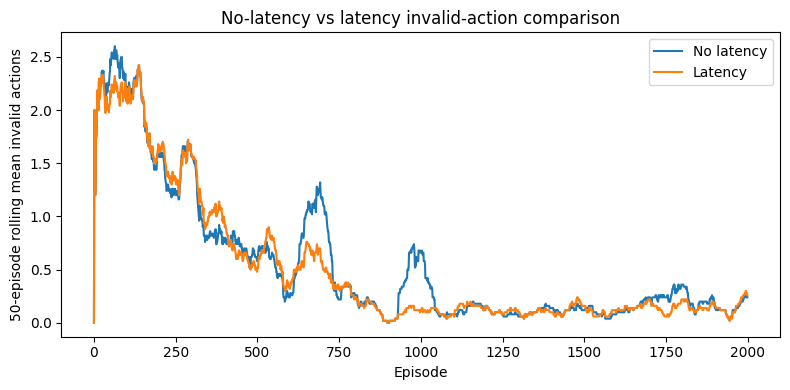

In [17]:
df_ep_latency["rolling_invalid_50"] = df_ep_latency["invalid_actions"].rolling(50, min_periods=1).mean()

plt.figure(figsize=(8, 4))
plt.plot(df_ep_no_latency["episode"], df_ep_no_latency["rolling_invalid_50"], label="No latency")
plt.plot(df_ep_latency["episode"], df_ep_latency["rolling_invalid_50"], label="Latency")
plt.xlabel("Episode")
plt.ylabel("50-episode rolling mean invalid actions")
plt.title("No-latency vs latency invalid-action comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
summary_no_latency.to_csv(runs_no_latency_dir / "doe_summary_no_latency.csv", index=False)
summary_latency.to_csv(runs_latency_dir / "doe_summary_latency.csv", index=False)
print("Saved CSV summary tables.")

Saved CSV summary tables.
